In [2]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams["figure.figsize"] = [12, 7.42]

In [4]:
N = 100000
rngs = np.random.rand(N)
means = np.zeros_like(rngs)

In [5]:
for i in range(len(rngs)):
    means[i] = np.mean(rngs[:i])
means = means[10:]

/home/nico/Scrivania/comp_phy/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nico/Scrivania/comp_phy/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


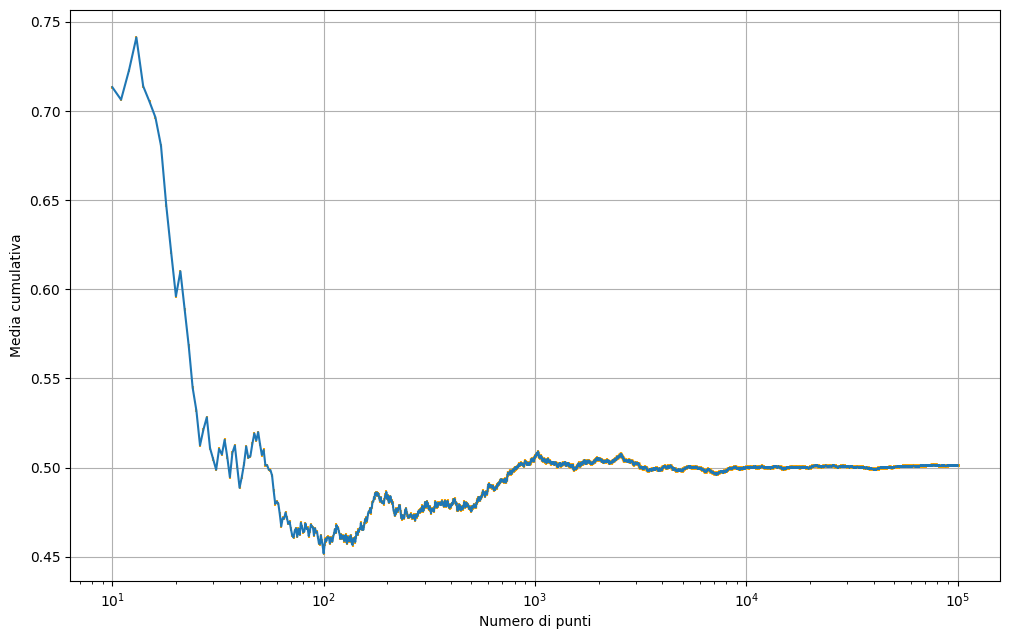

In [6]:
plt.errorbar(
    [x for x in range(10, N)],
    means,
    yerr=1/np.sqrt(12*N),
    ecolor="orange",
    markersize=5
)
plt.xscale("log")
plt.xlabel("Numero di punti")
plt.ylabel("Media cumulativa")
plt.grid()
plt.show()

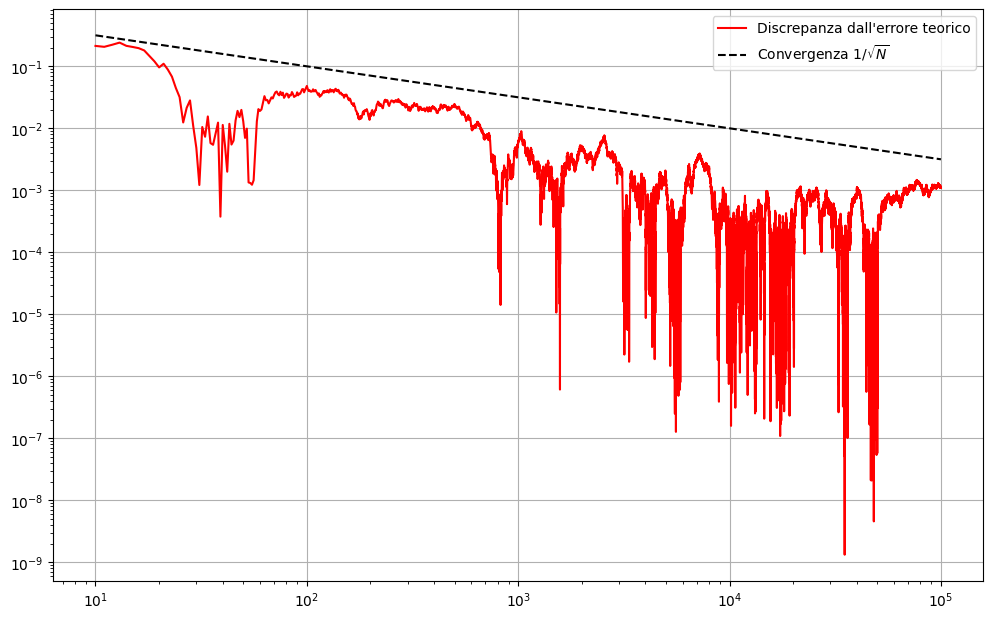

In [17]:
N_th = np.arange(10, len(means)+10)
err_th = 1 / np.sqrt(N_th)
plt.loglog(N_th, np.abs(means-0.5), color="red", label="Discrepanza dall'errore teorico")
plt.plot(N_th, err_th, "--", color="black", label=r"Convergenza $1/\sqrt{N}$")
plt.grid()
plt.legend()
plt.show()

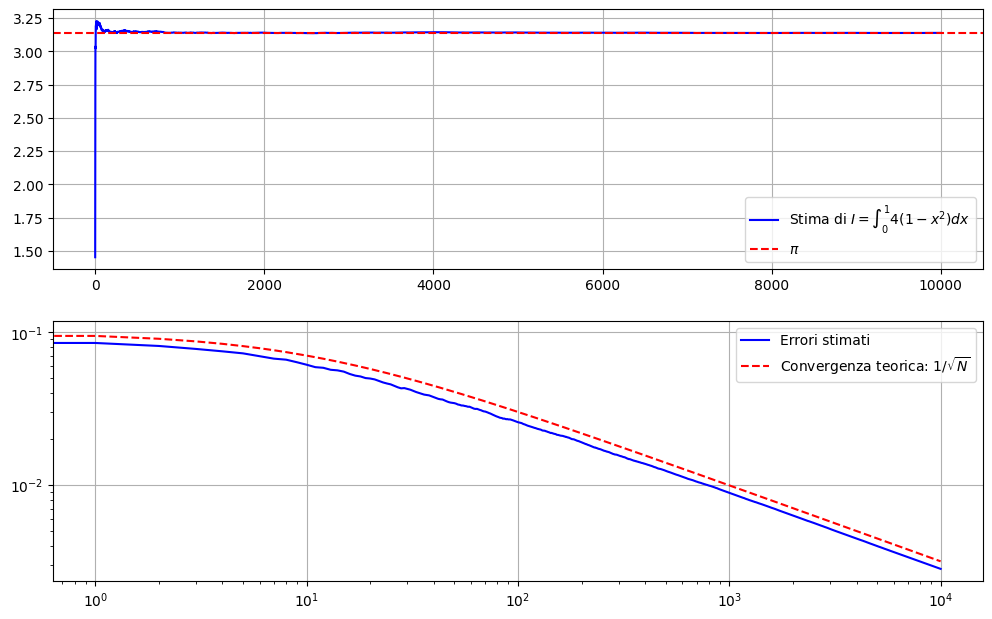

In [39]:
def f(x):
    return 4 * np.sqrt(1 - x**2)

def stimatore(rng: list[float], f: callable) -> float:
    return np.mean(f(rng))

Ns = np.linspace(1, 100_000, 10000).astype(int)
stime = np.zeros(len(Ns))
errs = np.zeros(len(Ns))

for i in range(len(Ns)):
    rng = rngs[:Ns[i]]
    stime[i] = stimatore(rng, f)
    sigma_f = np.std(f(rng))
    errs[i] = sigma_f / np.sqrt(Ns[i])

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(stime, color="blue", label=r"Stima di $I=\int_{0}^{1}4(1-x^2)dx$")
ax1.axhline(np.pi, ls="--", color="red", label=r"$\pi$")
ax1.grid(True)
ax1.legend()
ax2.plot(errs[10:], color="blue", label="Errori stimati")
ax2.plot(1/np.sqrt(Ns[10:]), "--", color="red", label=r"Convergenza teorica: $1/\sqrt{N}$")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(True)
ax2.legend()
plt.show()

In [9]:
def metropolis(lattice, J, T):
    """Metropolis algorithm for classical Ising model:
    choose a random point in the lattice and compute the variation of energy;
    if it's negative, accept the change; otherwise evaluate the transition probability 
    with the Boltzmann's distribution: exp(-beta E).
    """

    kb = 1.0
    N = lattice.shape[0]
    i, j = np.random.randint(0, N, size=2)
    spin = lattice[i, j]
    """ Sum over the nearest neighbors:
            [i-1,j]
               |
    [i,j-1]--[i,j]--[i,j+1]
               |
            [i+1,j]
    """
    neighbors_sum = lattice[i, (j-1)%N] + lattice[i, (j+1)%N] + lattice[(i-1)%N, j] + lattice[(i+1)%N, j]
    delta_energy = 2 * J * spin * neighbors_sum
    if delta_energy < 0:
        #The spin has only two values: +1, -1
        lattice[i, j] *= -1
    else:
        if np.random.rand() < np.exp(-delta_energy / (kb * T)):
            lattice[i, j] *= -1

In [110]:
def total_energy(lattice, L, J):
    energy = 0
    for i in range(L):
        for j in range(L):
            spin = lattice[i, j]
            neigh_sum = lattice[i, (j+1)%L] + lattice[(i+1)%L, j]
            energy += -J * spin * neigh_sum
    return energy

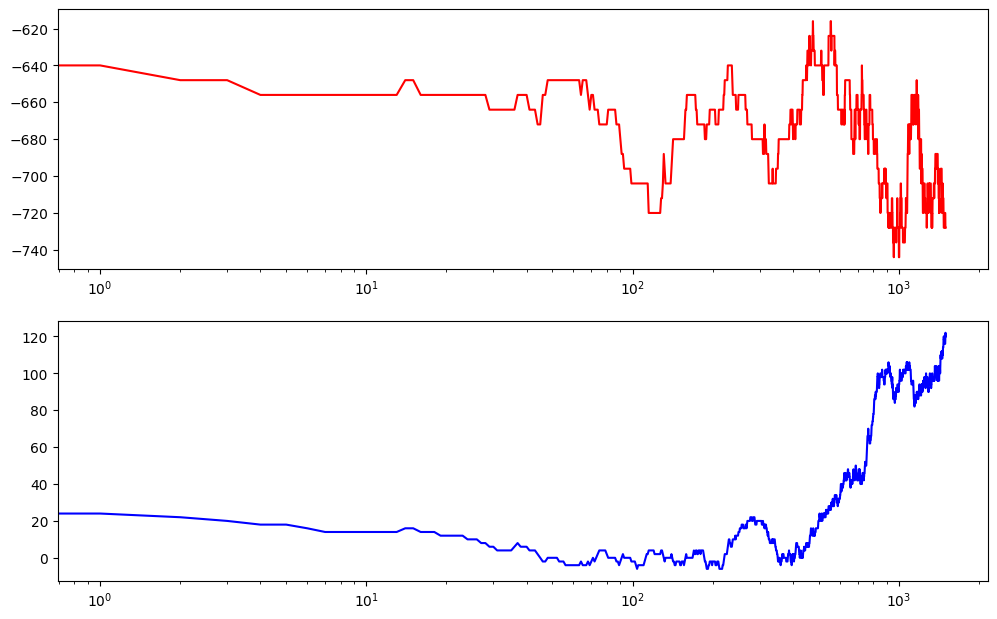

In [65]:
L = 20
J, T = 1.0, 2.669
term_steps = 750
measure_steps = 1500

lattice = np.random.choice([-1,1], size=(L, L))

# termalizzazione
for step in range(term_steps):
    metropolis(lattice, J, T)

energies, magn = [], []
for step in range(measure_steps):
    metropolis(lattice, J, T)
    energies.append(total_energy(lattice, L, J))
    magn.append(np.sum(np.sum(lattice)))

fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(energies, color="red", label=r"Energia a $T=2.0$")
ax1.set_xscale("log")
ax2.plot(magn, color="blue", label=r"Magnetizzazione a $T=2.0$")
ax2.set_xscale("log")
plt.show()

In [ ]:
temps = [1.0, 1.5, 2.0, 2.2, 2.3, 2.4, 2.5, 3.0, 4.0]
mean_en = np.zeros_like(temps)
mean_magn = np.zeros_like(temps)
N = L**2
term_steps, measure_steps = 500*L, 1500*L


for i in range(len(temps)):
    lattice = np.random.choice([-1,1], size=(L,L))
    
    for _ in range(term_steps):
        metropolis(lattice, J, temps[i])
    
    energies = np.zeros(measure_steps)
    magn = np.zeros(measure_steps)
    for step in range(measure_steps):
        metropolis(lattice, J, temps[i])
        energies[step] = total_energy(lattice, L, J)
        magn[step] = np.sum(np.sum(lattice))

    mean_en[i] = np.mean(energies) / N
    mean_magn[i] = np.mean(np.abs(magn)) / N

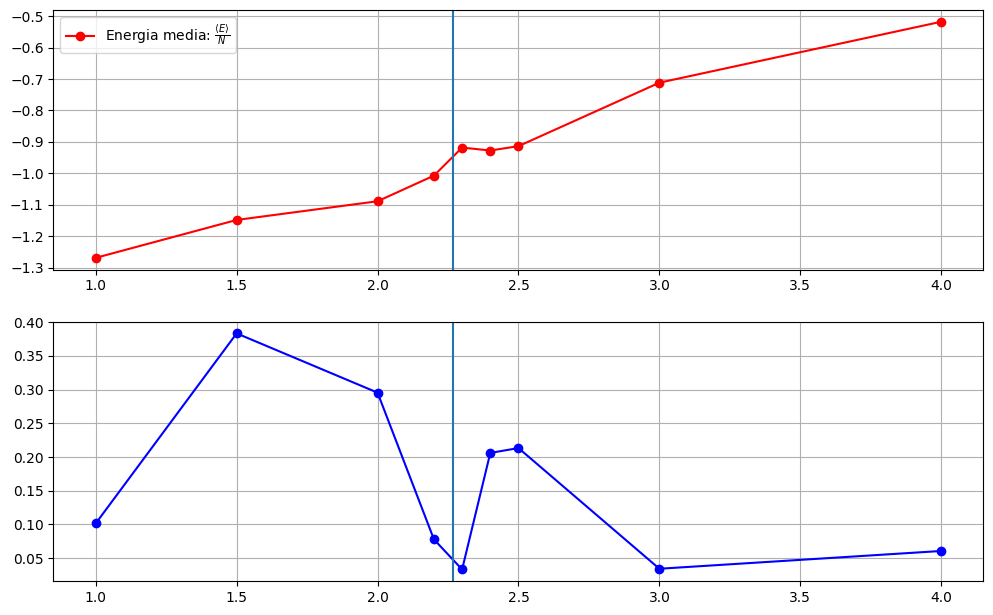

In [112]:
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(temps, mean_en, "-o", color="red", label=r"Energia media: $\frac{\langle E \rangle}{N}$")
ax1.legend()
ax2.plot(temps, mean_magn, "-o", color="blue", label=r"Magnetizzazione media: $\frac{\langle |M| \rangle}{N}$")
ax1.axvline(2.269)
ax2.axvline(2.269)
ax1.grid()
ax2.grid()
plt.show()

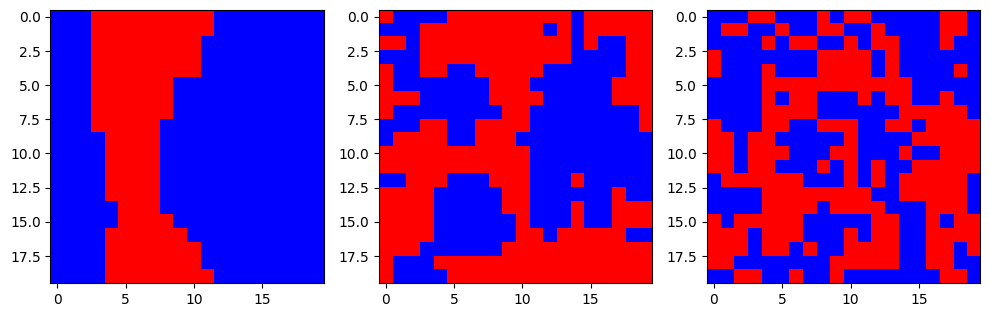

In [85]:
low_lattice = np.random.choice([-1,1], size=(L,L))
crit_lattice = np.random.choice([-1,1], size=(L,L))
high_lattice = np.random.choice([-1,1], size=(L,L))
CMAP = ListedColormap(["red", "blue"])
term_steps, measure_steps = 7500, 2000

for _ in range(term_steps):
    metropolis(low_lattice, J, 1.0)
    metropolis(crit_lattice, J, 2.269)
    metropolis(high_lattice, J, 4.0)

for _ in range(measure_steps):
        metropolis(low_lattice, J, 1.0)
        metropolis(crit_lattice, J, 2.269)
        metropolis(high_lattice, J, 4.0)
    

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
ax1.imshow(low_lattice, cmap=CMAP)
ax2.imshow(crit_lattice, cmap=CMAP)
ax3.imshow(high_lattice, cmap=CMAP)
plt.show()